# H3000 - Neblina

Hello :) Welcome to the rocketPy script for Neblina, Antares' project for the 2026 LASC.

## Nominal rocket
First, we'll define the idealized version of Neblina, without including any measurement uncertainties (which will be taken into account further down, in the 'Stochastic rocket' section)

In [ ]:
!pip install rocketpy
!pip install "pyvista[jupyter]"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 483.6/483.6 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 92.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 58.0 MB/s eta 0:00:00
  Created wheel for simplekml: filename=simplekml-1.3.6-py3-none-any.whl size=65860 sha256=95c71bd2c49b9c404a47eac3ec85aaee7ece9028d310240e5c168d8b972dbc9a
  Stored in directory: /root/.cache/pip/wheels/fd/2a/d1/84a7abdbb59566c442beb1b4fb946fe1e26c5a48fd1d5e0763
Successfully built simplekml
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.2/237.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 468.6/468.6 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 831.8/831.8 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip install pyvista trame
import pyvista as pv
pv.set_jupyter_backend("trame")

### Enviroment
Here, we define the launch place and weather conditions.

In [ ]:
from rocketpy import Environment, SolidMotor, Rocket, Flight, MonteCarlo
import datetime
import math
pi = math.pi
# We import these lines for debugging purposes, only works on Jupyter Notebook
#%load_ext autoreload
#%autoreload 2
#%matplotlib widget

In [ ]:
env = Environment(latitude= -21.943053, longitude= -48.954086, elevation= 490,
                  timezone= 'America/Sao_Paulo')

# Date does nothing currently, but we can use it to forecast the weather once the competition is closer.
tomorrow = datetime.date.today() + datetime.timedelta(days=1)
env.set_date(
    (tomorrow.year, tomorrow.month, tomorrow.day, 12)
)  # Hour given in UTC time

env.set_atmospheric_model(type="custom_atmosphere",
                          temperature= 298,
                          wind_u=[
                              (0, 15), # at 0 m
                              (1000, 15) # at 1000 m
                          ])


Gravity Details

Acceleration of gravity at surface level:    9.7860 m/s²
Acceleration of gravity at  80.000 km (ASL): 9.5452 m/s²


Launch Site Details

Launch Date: 2026-09-01 12:00:00 UTC
Launch Site Latitude: -21.94305°
Launch Site Longitude: -48.95409°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 91457.83 W    7568202.61 S
Launch Site UTM zone: 23K
Launch Site Surface Elevation: 490.0 m


Atmospheric Model Details

Atmospheric Model Type: custom_atmosphere
custom_atmosphere Maximum Height: 80.000 km

Surface Atmospheric Conditions

Surface Wind Speed: 15.00 m/s
Surface Wind Direction: 270.00°
Surface Wind Heading: 90.00°
Surface Pressure: 956.05 hPa
Surface Temperature: 298.00 K
Surface Air Density: 1.118 kg/m³
Surface Speed of Sound: 346.06 m/s


Earth Model Details

Earth Radius at Launch site: 6375.17 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75 km
Flattening: 0.0034


Atmospheric Model Plots



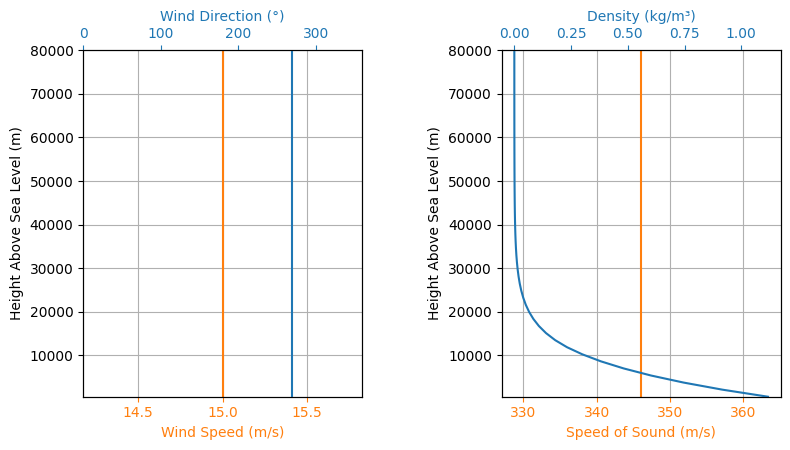

In [ ]:
env.info()

### Motor
Here we define Yaripo's physical and geometric properties

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
Yaripo = SolidMotor(
    thrust_source="/content/drive/MyDrive/Antares/H3000 - Neblina/02 - SImulações de voo/RocketPy/neblinaPy/data/Yaripo_teste_est_2_rocketpy.eng",
    coordinate_system_orientation= "combustion_chamber_to_nozzle",
    dry_mass= 0.976 + 3.432 + 3.017 + 0.991,   # TP + comb. chamb. + nozzle + therm. ins.     updated 28/07/26
    center_of_dry_mass_position= 0.358,   # Taken from CREO mass properties     updated 28/07/26
    dry_inertia= (0.54060753, 0.54060196, 0.025867792),   # Taken from CREO mass properties     updated 28/07/26
    nozzle_radius= 60 / 2000,
    grain_number=4,
    grain_density=1815,
    grain_outer_radius= 116 /2000,
    grain_initial_inner_radius= 40 / 2000,
    grain_initial_height= 129 / 1000,
    grain_separation= 2 /1000,
    grains_center_of_mass_position = 261 /1000,
    nozzle_position= 723.3 /1000,
    throat_radius= 20.6 / 2000,
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np

print("total_impulse:", Yaripo.total_impulse)
print("propellant_initial_mass:", Yaripo.propellant_initial_mass)
print("burn_time:", Yaripo.burn_time)
print("thrust tem NaN?", np.isnan(Yaripo.thrust.source[:, 1]).any())
print("thrust x é estritamente crescente?", np.all(np.diff(Yaripo.thrust.source[:, 0]) > 0))
print(Yaripo.thrust.source[:5])
print(Yaripo.thrust.source[-5:])

total_impulse: 9983.725855000004
propellant_initial_mass: 8.720761372762407
burn_time: (np.float64(0.0), np.float64(8.277))
thrust tem NaN? False
thrust x é estritamente crescente? True
[[0.    0.   ]
 [0.178 1.11 ]
 [0.267 1.11 ]
 [0.356 1.01 ]
 [0.445 1.   ]]
[[7.921 1.15 ]
 [8.01  1.05 ]
 [8.099 1.01 ]
 [8.188 0.92 ]
 [8.277 0.   ]]


Nozzle Details
Nozzle Radius: 0.03 m
Nozzle Throat Radius: 0.0103 m

Grain Details
Number of Grains: 4
Grain Spacing: 0.002 m
Grain Density: 1815 kg/m3
Grain Outer Radius: 0.058 m
Grain Inner Radius: 0.02 m
Grain Height: 0.129 m
Grain Volume: 0.001 m3
Grain Mass: 2.180 kg

Motor Details
Total Burning Time: 8.277 s
Total Propellant Mass: 8.721 kg
Structural Mass Ratio: 0.491
Average Propellant Exhaust Velocity: 1144.823 m/s
Average Thrust: 1206.201 N
Maximum Thrust: 4681.42 N at 2.937 s after ignition.
Total Impulse: 9983.726 Ns



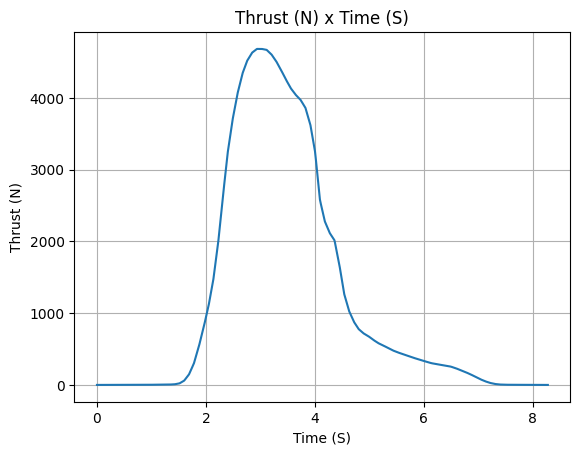

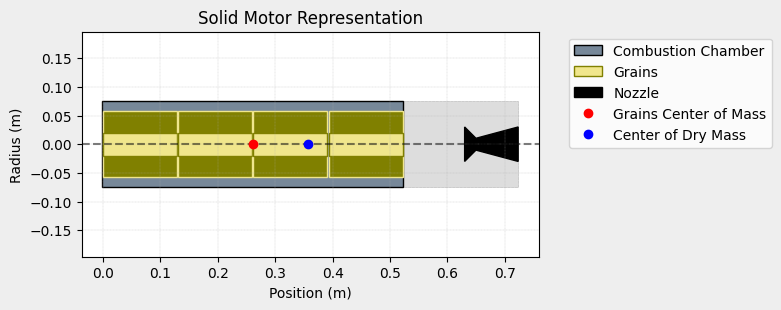

In [ ]:
Yaripo.info()
Yaripo.draw()

### Rocket body
Here we define the shape and postions of our rocket

In [ ]:
neblina = Rocket(
    radius= 156 /2000,
    mass= 17.003,   # mass without motor
    inertia= (5.38, 5.38, 0.075405296),   # Taken from Creo's Mass Properties function   #TODO: update later
    power_off_drag="/content/drive/MyDrive/Antares/H3000 - Neblina/02 - SImulações de voo/RocketPy/neblinaPy/data/cd_poweroff.CSV",   #TODO: update when CFD is done
    power_on_drag="/content/drive/MyDrive/Antares/H3000 - Neblina/02 - SImulações de voo/RocketPy/neblinaPy/data/cd_poweron.CSV",   #TODO: update when CFD is done
    center_of_mass_without_motor= 1.285,
    coordinate_system_orientation="nose_to_tail",
)

neblina.add_motor(Yaripo, position= 2.1755)

rail_buttons = neblina.set_rail_buttons(
    upper_button_position= 1.500,
    lower_button_position= 2.650,
    angular_position=45,
)

nose_cone = neblina.add_nose(
    length= 550 /1000, kind = "von karman", position = 0
)

fin_set = neblina.add_trapezoidal_fins(
    n=4,
    root_chord=0.300,
    tip_chord=0.075,
    span=0.170,
    position= 2.494,
    sweep_angle= 50,
    # airfoil=("../data/airfoils/NACA0012-radians.txt","radians"), #TODO: this
)

tail = neblina.add_tail(
    top_radius= 156 /2000, bottom_radius= 100 /2000, length= 198 /1000, position= 2.684
)


cd_main = 0.87
mainDiam = 2.6
spillHoleArea = pi * ((3.2*0.2) /2)**2
mainRadius = mainDiam / 2
mainArea = (pi * (mainDiam / 2) ** 2) - spillHoleArea

main = neblina.add_parachute(
    name="main",
    cd_s=cd_main * mainArea,
    trigger= 400,      # AGL ejection altitude
    sampling_rate=100,
    lag=2,
    noise=(0, 8.3, 0.5),
    radius= mainRadius,
    height=0.7 * mainRadius,
    porosity=0.0432,
)

cd_drogue = 0.22
drogueDiam = 1.0
drogueRadius = drogueDiam / 2
drogueArea = (pi * drogueRadius ** 2) - spillHoleArea

drogue = neblina.add_parachute(
    name="drogue",
    cd_s= cd_drogue * drogueArea,
    trigger="apogee",  # ejection at apogee
    sampling_rate=100,
    lag=1,
    noise=(0, 8.3, 0.5),
    radius= drogueRadius,
    porosity=0.0432,
)

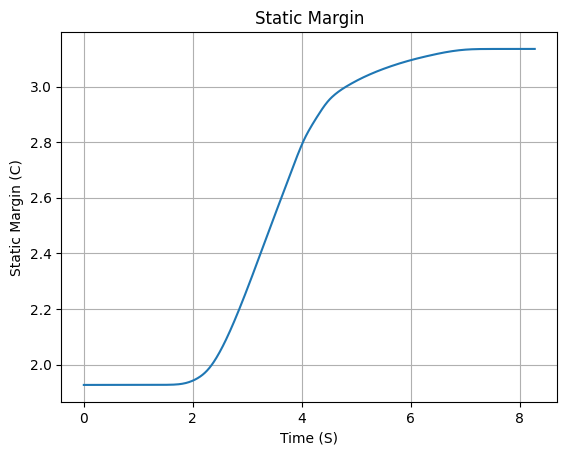

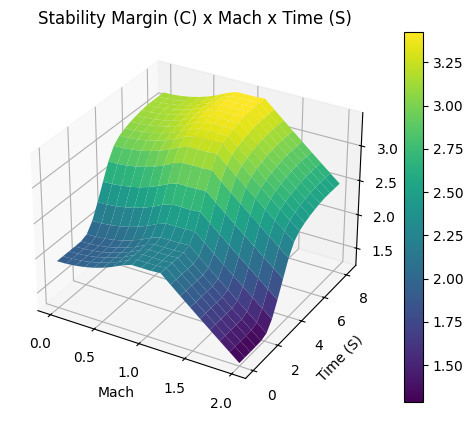

In [ ]:
neblina.plots.static_margin()
neblina.plots.stability_margin()

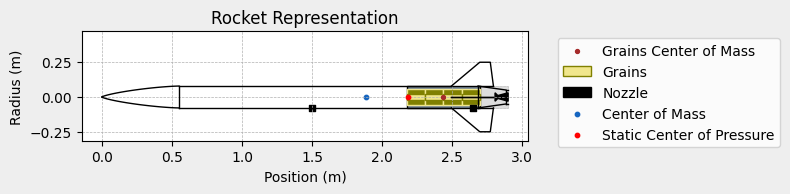

In [ ]:
neblina.draw()
neblina.draw(filename="neblina.png")


### Run simulation
Run it!

In [1]:
flight = Flight(
    rocket=neblina, environment=env, rail_length=6.0, inclination=80, heading=90
    )

NameError: name 'Flight' is not defined

In [ ]:
flight.info()
# test_flight.all_info()


Initial Conditions

Initial time: 0.000 s
Position - x: 0.00 m | y: 0.00 m | z: 490.00 m
Velocity - Vx: 0.00 m/s | Vy: 0.00 m/s | Vz: 0.00 m/s
Attitude (quaternions) - e0: -0.381 | e1: 0.081 | e2: -0.033 | e3: 0.920
Euler Angles - Spin φ : -45.00° | Nutation θ: -10.00° | Precession ψ: 270.00°
Angular Velocity - ω1: 0.00 rad/s | ω2: 0.00 rad/s | ω3: 0.00 rad/s
Initial Stability Margin: 1.927 c


Surface Wind Conditions

Frontal Surface Wind Speed: 15.00 m/s
Lateral Surface Wind Speed: -0.00 m/s


Launch Rail

Launch Rail Length: 6.0 m
Launch Rail Inclination: 80.00°
Launch Rail Heading: 90.00°


Rail Departure State

Rail Departure Time: 0.000 s
Rail Departure Velocity: 0.000 m/s
Rail Departure Stability Margin: 1.927 c
Rail Departure Angle of Attack: 100.000°
Rail Departure Thrust-Weight Ratio: 0.000
Rail Departure Reynolds Number: 1.424e+05


Burn out State

Burn out time: 8.277 s
Altitude at burn out: 490.000 m (ASL) | 0.000 m (AGL)
Rocket speed at burn out: 0.000 m/s
Freestream vel

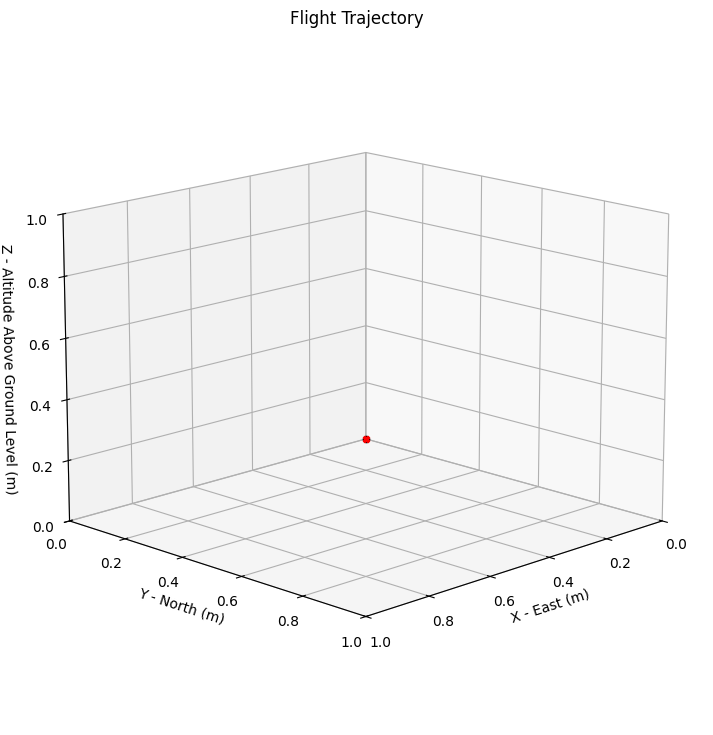

In [ ]:
flight.plots.trajectory_3d()

In [ ]:
#Dispersion ratio
dispersion_ratio= (((448.513)**2)+((-0.205)**2))**(1/2)
print(dispersion_ratio)

448.5130468492527


### Further analysis

/usr/local/lib/python3.13/dist-packages/rocketpy/simulation/flight.py:610: UnstableRocketWarning: The rocket has a negative static margin (-0.17 cal) at motor ignition (t=0), indicating an aerodynamically unstable configuration. Check the placement of fins and nose cone relative to the center of mass.
  self.rocket.warn_if_unstable()
/usr/local/lib/python3.13/dist-packages/rocketpy/mathutils/_calc/polation_1d.py:119: RuntimeWarning: invalid value encountered in divide
  self._slopes = np.diff(self._y) / np.diff(self._x)
/usr/local/lib/python3.13/dist-packages/rocketpy/mathutils/_calc/polation_1d.py:119: RuntimeWarning: divide by zero encountered in divide
  self._slopes = np.diff(self._y) / np.diff(self._x)


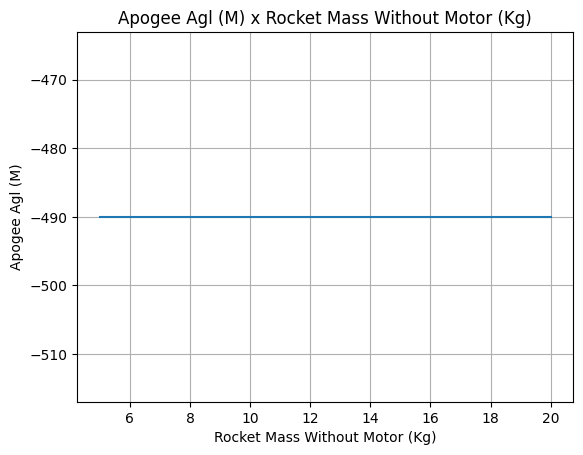

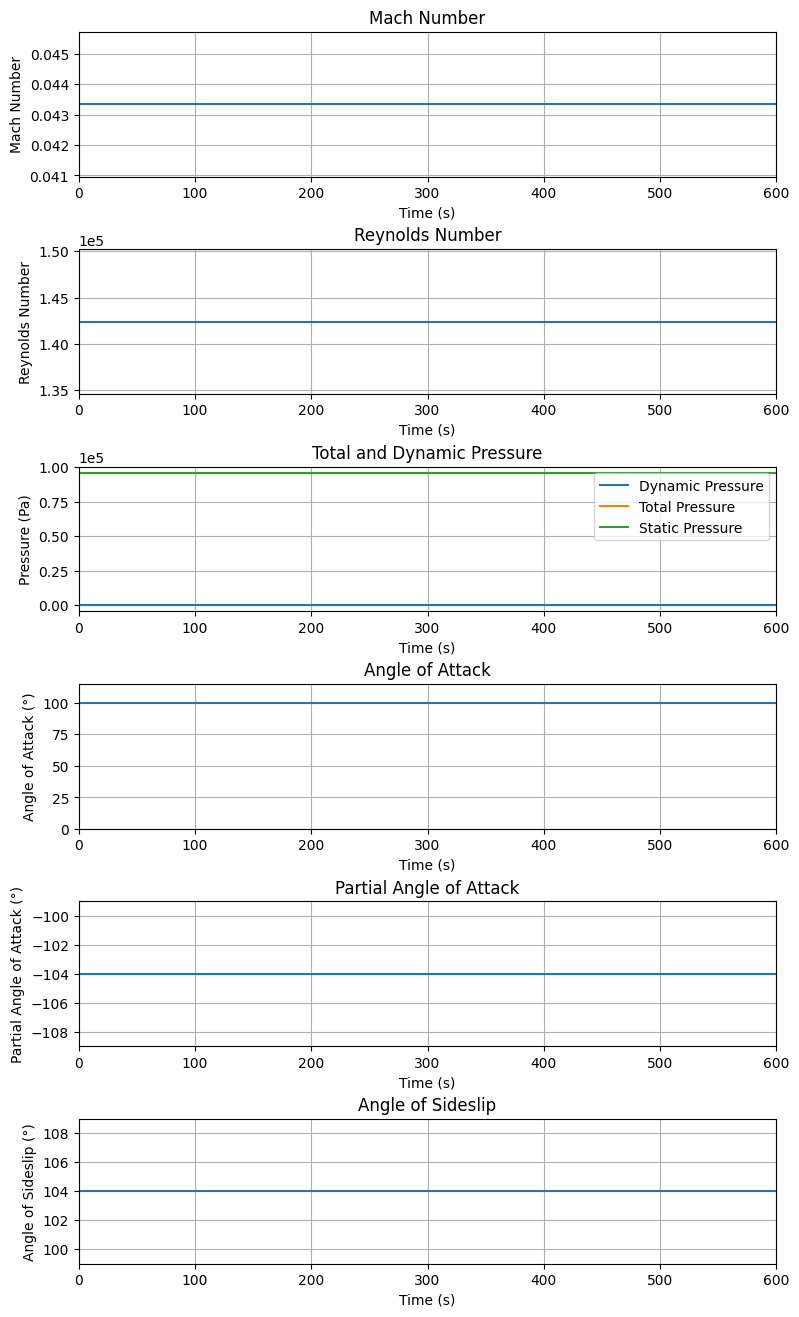

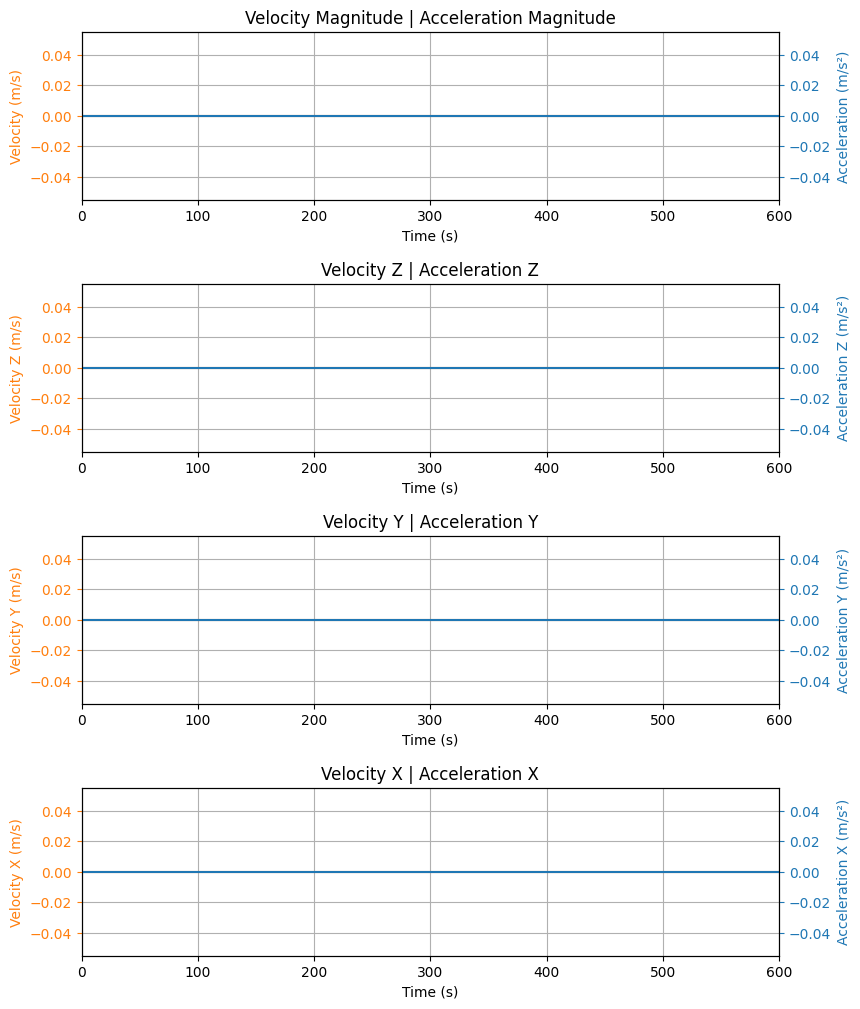

In [ ]:
from rocketpy.utilities import apogee_by_mass

apogee_by_mass(
    flight=flight, min_mass=5, max_mass=20, points=10, plot=True
    )

# Aerodynamics plots
flight.plots.fluid_mechanics_data()

# Velocity and acceleration plots
flight.plots.linear_kinematics_data()

## Stochastic rocket

Now, we define uncertainties to certain parameters, in order to evaluate how they'll affect our flight.

For now the Monte Carlo analysis as been removed until we fix our ensemble model. We'll probably have it running by next week, but not in time for the next delivery.